# Ultraheavy dark matter with a finite-range mediator

The [momentum-kick tutorial](TUTORIAL_UHDM.md) used a *massless* mediator, where
the rate factorizes as $(\alpha_n N_n)^2 \times$ a fixed spectrum shape and
`OptimumIntervalTable.upper_limit` applies directly. For a mediator of **finite
range** $\lambda$ that factorization breaks: the momentum transfer from a flyby
at impact parameter $b$ is

$$q(b) \simeq \frac{2\,\alpha}{\lambda v}\, G_2\!\left(\tfrac{R_\text{eff}}{\lambda}\right) K_1\!\left(\tfrac{b}{\lambda}\right),
\qquad \alpha = \alpha_n N_n,$$

so the kinematic endpoint and the whole shape of $dR/dq$ move with the coupling
$\alpha_n$, the parameter we are limiting. This notebook shows the right pattern
for that case: **scan the coupling**, and at each candidate $\alpha_n$ evaluate
the optimum-interval extremeness with the package *primitives* (`generate`,
`optimum_interval_statistic`, `extremeness_of_opt_itv_stat`), using that
coupling's own spectrum. The package stays "events + shape in, statistics out";
all physics lives here.

The search plans **seven mediator ranges** in decade steps,

$$\lambda = 2\ \text{m},\ 2\ \text{cm},\ 2\ \text{mm},\ 200\ \text{µm},\
20\ \text{µm},\ 2\ \text{µm},\ 0.2\ \text{µm},$$

spanning $\xi \equiv R_\text{eff}/\lambda$ from $10^{-3}$ to $10^{3}$ around
the sensor radius $R_\text{eff}$ = 200 µm; we carry all seven through the same
pipeline. Couplings are shown up to $\alpha_n = 1$ and masses up to the Planck
mass. The notebook is organized as: input, physics model, statistics, scan,
results, understanding.

Inputs: the standard-halo-model velocity distribution, classical scattering of
a pointlike heavy particle off a finite-size levitated magnet through a Yukawa
potential, and a toy set of candidate kicks. **All experimental parameters are
illustrative fiducials** (a levitated-magnet impulse search of the kind in
[arXiv:2409.03814](https://arxiv.org/abs/2409.03814)); substitute your own.


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
from scipy.special import erf, kve

from optimum_interval import (
    OptimumIntervalTable,
    poisson_upper_limit,
    spectrum_cdf_from_samples,
)

RNG_SEED = 20260702

# --- fiducial constants (natural units: GeV, c = 1) ---
C_M_S = 299792458.0
V0 = 220e3 / C_M_S              # halo velocity dispersion parameter
VESC = 544e3 / C_M_S            # galactic escape velocity
RHO_DM = 2.3e-42                # 0.3 GeV/cm^3 in GeV^4
GEV_PER_S = 1.519e24            # 1 GeV of rate = 1.519e24 s^-1

M_MAG_KG = 0.42e-6              # levitated magnet mass
N_NEUTRONS = M_MAG_KG / 1.67e-27  # fiducial: count all nucleons
R_EFF = 0.2e-3                  # magnet effective radius [m] (200 microns)
Q_TH = 8.4e3                    # momentum threshold [GeV]
T_OBS_S = 3600 * 24 * 14.0      # two weeks of livetime
CONFIDENCE = 0.95
M_PLANCK = 1.22e19              # GeV

# the seven mediator ranges planned for the search, largest first
LAMBDAS = [
    (r"$\lambda$ = 2 m", 2.0, "#1f77b4"),
    (r"$\lambda$ = 2 cm", 2e-2, "#ff7f0e"),
    (r"$\lambda$ = 2 mm", 2e-3, "#2ca02c"),
    (r"$\lambda$ = 200 µm ($R_{\rm eff}$)", 2e-4, "#d62728"),
    (r"$\lambda$ = 20 µm", 2e-5, "#9467bd"),
    (r"$\lambda$ = 2 µm", 2e-6, "#8c564b"),
    (r"$\lambda$ = 0.2 µm", 2e-7, "#e377c2"),
]

def m_to_per_gev(x):
    '''meters -> GeV^-1'''
    return 5.0679e6 * x * 1e9

print(f"N_n = {N_NEUTRONS:.2e},  R_eff = {R_EFF * 1e6:.0f} um")

N_n = 2.51e+20,  R_eff = 200 um


## Input: toy candidate kicks

Four transients just above threshold plus one outlier (the same toy dataset as
the massless-mediator example). These stand in for reconstructed momentum
transfers from data; replace the array and rerun.


In [2]:
KICKS = np.array([8600.0, 8900.0, 9300.0, 9800.0, 30000.0])   # GeV
print(f"candidate kicks [GeV]: {KICKS}")

candidate kicks [GeV]: [ 8600.  8900.  9300.  9800. 30000.]


## Physics model

### Velocity distribution: the standard halo model

A truncated Maxwellian with dispersion $\sigma_v = v_0/\sqrt{2}$, normalized on
$[0, v_\text{esc}]$:

$$f(v) = \frac{4\pi v^2}{(2\pi\sigma_v^2)^{3/2}\,N_\text{esc}}\;
e^{-v^2/2\sigma_v^2}\;\Theta(v_\text{esc}-v).$$


In [3]:
SIG_V = V0 / np.sqrt(2)
N_ESC = erf(VESC / V0) - np.sqrt(2 / np.pi) * (VESC / SIG_V) * np.exp(
    -(VESC**2) / (2 * SIG_V**2)
)

def f_halo(v):
    '''SHM speed distribution, normalized so its integral over [0, v_esc] is 1.'''
    return (4 * np.pi * v**2 / ((2 * np.pi * SIG_V**2) ** 1.5 * N_ESC)
            * np.exp(-(v**2) / (2 * SIG_V**2)) * np.heaviside(VESC - v, 0.0))

v_check = np.linspace(0, VESC, 4000)
print(f"normalization check: integral = {np.trapezoid(f_halo(v_check), v_check):.6f}")

normalization check: integral = 0.999991


### Cross section: finite-range Yukawa, finite-size sensor

The sensor's finite size enters through the shape factor
$G_2(x) = 3(x\cosh x - \sinh x)/x^3$, and the impulse is measured as a
*projection* on the sensitive axis. In the dimensionless variable
$\tilde q \equiv q\,\lambda v / (2\alpha G_2)$ the projected differential cross
section is

$$\frac{d\sigma}{d\tilde q} = \int_0^{\cosh^{-1}(K_1(\xi)/\tilde q)}
\frac{\beta(\kappa)}{|K_1'(\beta(\kappa))|}\,dt,
\qquad \kappa = \tilde q \cosh t,$$

where $\beta(\kappa)$ inverts $K_1$ and $\xi \equiv R_\text{eff}/\lambda$. The
support ends at $\tilde q_\text{max} = K_1(\xi)$: a finite-range mediator
**caps the momentum transfer**, which is what creates a hard sensitivity floor
in the coupling. Across the seven planned ranges $\xi$ spans $10^{-3}$ to
$10^{3}$. For $\xi \gg 1$ the cap collapses as $K_1(\xi) \sim e^{-\xi}$,
partly bought back by $G_2 \sim e^{\xi}/\xi^2$: the physical product $G_2 K_1$
falls only polynomially, $\sim \xi^{-5/2}$. Because $K_1(\xi)$ and $G_2(\xi)$
separately under/overflow float64 beyond $\xi \approx 700$, the tabulation
works entirely in **log space** (scipy's exponentially scaled Bessel `kve`),
parameterized by the distance below the cap,
$\Delta \equiv \ln(\tilde q_\text{max}/\tilde q)$. We tabulate
$\ln(d\sigma/d\tilde q)$ once per range and interpolate.


In [4]:
def ln_shape_factor(x):
    # ln G2(x); G2 = 3[e^x(x-1)/2 + e^-x(x+1)/2]/x^3, evaluated stably
    if x < 30:
        return float(np.log(3.0 * (x * np.cosh(x) - np.sinh(x)) / x**3))
    return float(np.log(1.5 * (x - 1)) + x - 3 * np.log(x))

def ln_k1(beta):
    # ln K1(beta) via the exponentially scaled kve(1, x) = K1(x) e^x
    return np.log(kve(1, beta)) - beta

# invert ln K1 (monotone decreasing) on a grid wide enough for xi = 1000
_beta_grid = np.geomspace(1e-4, 2000.0, 20000)
_lnk1_grid = ln_k1(_beta_grid)
_beta_of_lnk1 = interp1d(_lnk1_grid[::-1], _beta_grid[::-1])

def beta_of_ln_kappa(ln_kappa):
    # beta such that ln K1(beta) = ln_kappa (1/kappa asymptote above the grid)
    ln_kappa = np.asarray(ln_kappa, float)
    hi = ln_kappa > _lnk1_grid[0]
    out = np.empty_like(ln_kappa)
    out[hi] = np.exp(-ln_kappa[hi])
    out[~hi] = _beta_of_lnk1(np.clip(ln_kappa[~hi], _lnk1_grid[-1], _lnk1_grid[0]))
    return out

DELTA_MAX = 32.0   # tabulate down to q_tilde = q_tilde_max * exp(-32)

def make_xsec(lamb):
    # tabulate ln(dsigma/dq_tilde) vs Delta = ln(qt_max/qt) for one range
    xi = R_EFF / lamb
    ln_G2 = ln_shape_factor(xi)
    ln_qt_max = float(ln_k1(xi))                     # ln K1(xi)
    ln_G2K1 = ln_G2 + ln_qt_max                      # ln(G2 K1), the physical cap

    def ln_ds(delta):
        # dsigma/dq_tilde = int_0^{arccosh(e^Delta)} beta / |K1'(beta)| dt
        t_max = np.arccosh(np.exp(delta)) if delta < 30 else delta + np.log(2.0)
        ts = np.linspace(0.0, t_max, 800)
        ln_kappa = (ln_qt_max - delta) + np.log(np.cosh(ts))
        beta = beta_of_ln_kappa(ln_kappa)
        # |K1'| = (K0 + K2)/2; the e^beta factors carried in logs
        ln_int = np.log(beta) - np.log(0.5 * (kve(0, beta) + kve(2, beta))) + beta
        m = ln_int.max()
        return m + np.log(np.trapezoid(np.exp(ln_int - m), ts))

    deltas = np.linspace(1e-4, DELTA_MAX, 400)
    tab = interp1d(deltas, [ln_ds(d) for d in deltas],
                   bounds_error=False, fill_value=-np.inf)
    return dict(lamb=lamb, lamb_gev=m_to_per_gev(lamb), xi=xi,
                ln_G2=ln_G2, ln_G2K1=ln_G2K1, tab=tab)

XSECS = [(label, make_xsec(lamb), color) for label, lamb, color in LAMBDAS]
print(f"{'lambda':>10} {'xi':>9} {'G2*K1':>10}")
for label, xs, _ in XSECS:
    lam = xs["lamb"]
    pretty = f"{lam:.0f} m" if lam >= 1 else (
        f"{lam * 1e3:.0f} mm" if lam >= 1e-3 else f"{lam * 1e6:.1f} um")
    print(f"{pretty:>10} {xs['xi']:>9.3f} {np.exp(xs['ln_G2K1']):>10.3e}")

def dsigma_dq(q, alpha, v, xs):
    # physical dsigma/dq in GeV^-3 (q in GeV, v in units of c); vectorized in v.
    # Delta = ln(qt_max/qt) = ln(2 alpha G2 K1) - ln(q lambda v)
    delta = np.log(2 * alpha) + xs["ln_G2K1"] - np.log(q * xs["lamb_gev"] * v)
    ln_ds = xs["tab"](delta)
    return np.exp(ln_ds + 3 * np.log(xs["lamb_gev"]) + np.log(v)
                  - np.log(alpha) - xs["ln_G2"])

    lambda        xi      G2*K1
       2 m     0.000  1.000e+04
     20 mm     0.010  9.997e+01
      2 mm     0.100  9.864e+00
  200.0 um     1.000  6.643e-01
   20.0 um    10.000  5.545e-03
    2.0 um   100.000  1.868e-05
    0.2 um  1000.000  5.941e-08


### Differential rate

$$\frac{dR}{dq} = n_\text{DM} \int_{v_\text{min}(q)}^{v_\text{esc}}
f(v)\, v\, \frac{d\sigma}{dq}(q, v)\, dv,
\qquad v_\text{min} = q/m_\text{DM},\quad n_\text{DM} = \rho_\text{DM}/m_\text{DM}.$$

Note the finite-range peculiarity visible below: $q(b)\propto 1/v$, so *slow*
particles deliver the largest kicks, and the spectrum endpoint is set by the
interplay of $\tilde q < K_1(\xi)$ with $v \ge v_\text{min}$. At fixed coupling
the spectrum weakens and steepens as the range shrinks; for
$\lambda \gtrsim 2$ cm the endpoint sits at the halo kinematic limit
$q = m_\text{DM} v_\text{esc}$ (effectively massless).


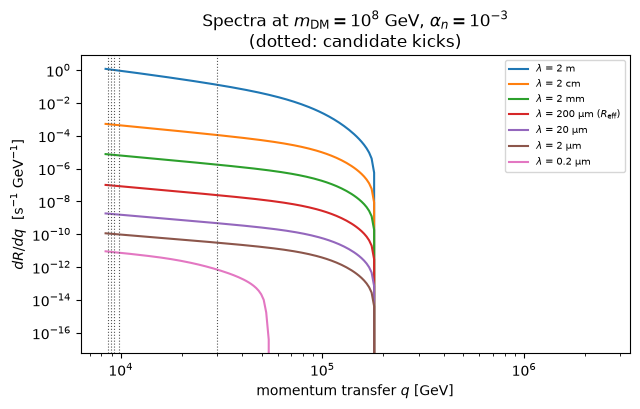

In [5]:
def drdq(qs, alpha_n, m_dm, xs):
    '''dR/dq in s^-1 GeV^-1 on the array qs.'''
    alpha = alpha_n * N_NEUTRONS
    n_dm = RHO_DM / m_dm
    out = np.zeros_like(qs)
    for i, q in enumerate(qs):
        v_min = q / m_dm
        if v_min >= VESC:
            continue
        vs = np.geomspace(max(v_min, 1e-6), VESC, 300)
        out[i] = np.trapezoid(n_dm * f_halo(vs) * vs * dsigma_dq(q, alpha, vs, xs), vs)
    return np.maximum(out, 0.0) * GEV_PER_S

qs_plot = np.geomspace(Q_TH, 300 * Q_TH, 200)
fig, ax = plt.subplots(figsize=(6.5, 4.2))
for label, xs, color in XSECS:
    ax.loglog(qs_plot, drdq(qs_plot, 1e-3, 1e8, xs), color=color, label=label)
for q_ev in KICKS:
    ax.axvline(q_ev, color="#555555", lw=0.8, ls=":")
ax.set_xlabel(r"momentum transfer $q$ [GeV]")
ax.set_ylabel(r"$dR/dq$  [s$^{-1}$ GeV$^{-1}$]")
ax.set_title(r"Spectra at $m_{\rm DM} = 10^8$ GeV, $\alpha_n = 10^{-3}$"
             "\n(dotted: candidate kicks)")
ax.legend(fontsize=7)
fig.tight_layout()

## Statistics: the coupling-grid pattern

Because the spectrum shape depends on $\alpha_n$, we cannot solve for a single
$\mu$ upper limit and convert it. Instead, for each mediator range and each
mass we scan $\alpha_n$ up to 1, and at each grid point:

1. build that coupling's spectrum $dR/dq$, its support window, and
   $\mu(\alpha_n) = T_\text{obs}\int dR/dq\,dq$;
2. keep only candidates inside the window (kicks beyond the endpoint cannot be
   signal at this coupling);
3. evaluate the optimum-interval **extremeness** of the data at
   $(\mu, \text{shape})$ with the package primitives;
4. interpolate where the extremeness crosses the confidence level.

Two shortcuts keep it fast: $\mu$ is rounded to a 2%-spaced log grid so the
Monte-Carlo calibration tables are shared across ranges, masses, and couplings,
and $\mu > 40$ with $\le 5$ observed events is excluded outright (extremeness
indistinguishable from 1).


In [6]:
N_MC = 10000   # enough to resolve cases that sit at the 95% knife edge
table = OptimumIntervalTable(rng=np.random.default_rng(RNG_SEED))

def round_log(x, dex=0.02):
    return 10 ** (np.round(np.log10(x) / dex) * dex)

def spectrum_at(alpha_n, m_dm, xs, n_q=160):
    '''Return (mu, cdf, q_lo, q_hi) for this coupling and mass, or None if no support.'''
    qs = np.geomspace(Q_TH, 1000 * Q_TH, n_q)
    rate = drdq(qs, alpha_n, m_dm, xs)
    if not np.any(rate > 0):
        return None
    hi = np.max(np.where(rate > 0)[0])
    qs, rate = qs[: hi + 1], rate[: hi + 1]
    mu = float(np.trapezoid(rate, qs)) * T_OBS_S
    cum = np.concatenate([[0.0], np.cumsum(0.5 * (rate[1:] + rate[:-1]) * np.diff(qs))])
    if cum[-1] <= 0:
        return None
    cdf = spectrum_cdf_from_samples(qs, cum / cum[-1])
    return mu, cdf, qs[0], qs[-1]

def extremeness(alpha_n, m_dm, xs):
    '''(extremeness, mu, n_inside) at this coupling, or None if no support.'''
    spec = spectrum_at(alpha_n, m_dm, xs)
    if spec is None:
        return None
    mu, cdf, q_lo, q_hi = spec
    inside = KICKS[(KICKS > q_lo) & (KICKS < q_hi)]
    if mu < 0.2:
        return 0.0, mu, inside.size
    if mu > 40.0:
        return 1.0, mu, inside.size   # <= 5 events observed: overwhelmingly excluded
    mu_r = round_log(mu)
    table.generate(mu_r, N_MC)
    stat = table.optimum_interval_statistic(inside, mu_r, spectrum_cdf=cdf)
    return table.extremeness_of_opt_itv_stat(stat, mu_r), mu, inside.size

def crossing(alphas, values, level):
    '''First alpha where values (increasing-ish) cross level, log-interpolated.'''
    values = np.asarray(values, float)
    above = values >= level
    if not above.any() or above.all():
        return np.nan
    i = int(np.argmax(above))
    if i == 0:
        return alphas[0]
    x0, x1 = np.log10(alphas[i - 1]), np.log10(alphas[i])
    y0, y1 = values[i - 1], values[i]
    return 10 ** (x0 + (level - y0) * (x1 - x0) / (y1 - y0))

## The scan

For each of the seven ranges: masses from the kinematic floor to the Planck
mass, couplings $10^{-9}$ to 1. Alongside the optimum-interval crossing we
record two counting benchmarks from the same $\mu(\alpha_n)$ curves: Poisson
with the in-window candidates, and the zero-event ideal
$\langle N\rangle \simeq 3$.


In [7]:
masses = np.geomspace(6e6, M_PLANCK, 37)
alpha_scan = np.geomspace(1e-9, 1.0, 41)

scan = {}
for label, xs, color in XSECS:
    a_oi, a_pois, a_ideal, mu_max = [], [], [], []
    for m_dm in masses:
        ps, mus, n_in = [], [], []
        for a in alpha_scan:
            out = extremeness(a, m_dm, xs)
            p, mu, k = out if out is not None else (0.0, 0.0, 0)
            ps.append(p)
            mus.append(mu)
            n_in.append(k)
        ps, mus = np.array(ps), np.array(mus)
        a_oi.append(crossing(alpha_scan, ps, CONFIDENCE))
        # counting comparisons from the same mu(alpha) scan
        a_ideal.append(crossing(alpha_scan, mus, poisson_upper_limit(0, CONFIDENCE)))
        pois_levels = np.array([poisson_upper_limit(k, CONFIDENCE) for k in n_in])
        a_pois.append(crossing(alpha_scan, mus - pois_levels, 0.0))
        mu_max.append(mus.max())
    scan[label] = dict(a_oi=np.array(a_oi), a_pois=np.array(a_pois),
                       a_ideal=np.array(a_ideal), mu_max=np.array(mu_max),
                       color=color, xs=xs)
    a = scan[label]["a_oi"]
    ok = np.isfinite(a)
    if ok.any():
        print(f"{label}: excluded for m in [{masses[ok].min():.1e}, "
              f"{masses[ok].max():.1e}] GeV; strongest alpha_n = {np.nanmin(a):.2e}")
    else:
        print(f"{label}: no 95% exclusion at any mass for alpha_n <= 1 "
              f"(max mu over the whole plane = {scan[label]['mu_max'].max():.1f})")

$\lambda$ = 2 m: excluded for m in [6.0e+06, 2.5e+18] GeV; strongest alpha_n = 1.30e-08


$\lambda$ = 2 cm: excluded for m in [6.0e+06, 9.6e+14] GeV; strongest alpha_n = 1.30e-08


$\lambda$ = 2 mm: excluded for m in [6.0e+06, 8.6e+12] GeV; strongest alpha_n = 1.30e-08


$\lambda$ = 200 µm ($R_{\rm eff}$): excluded for m in [6.0e+06, 1.7e+11] GeV; strongest alpha_n = 2.37e-08


$\lambda$ = 20 µm: excluded for m in [1.3e+07, 1.5e+09] GeV; strongest alpha_n = 4.96e-07


$\lambda$ = 2 µm: excluded for m in [2.9e+07, 2.9e+07] GeV; strongest alpha_n = 5.30e-02


$\lambda$ = 0.2 µm: no 95% exclusion at any mass for alpha_n <= 1 (max mu over the whole plane = 0.4)


## Results: the seven planned ranges

The 95% CL exclusion for all seven mediator ranges, up to the Planck mass and
$\alpha_n \le 1$. The momentum cap $\tilde q_\text{max} = K_1(\xi)$ organizes
the whole family:

- **Coupling floors.** The three longest ranges (2 m, 2 cm, 2 mm) share the
  same floor, $\alpha_n \approx 1.3\times10^{-8}$: at low mass they are all in
  the Coulomb regime and the cap is irrelevant. From
  $\lambda = R_\text{eff}$ down, the cap raises the floor (the $\mu$ cliff in
  the anatomy below).
- **High-mass endpoints from reach saturation.** Once the impact parameters
  needed for a kick exceed $\lambda$, the reach grows only as
  $\lambda\ln\alpha$, the cross section saturates at $\sim\lambda^2$, and the
  falling number density $1/m$ wins. The endpoints stratify by roughly a
  factor 100 per decade of range: $1.5\times10^{9}$ GeV (20 µm),
  $1.7\times10^{11}$ (200 µm), $8.6\times10^{12}$ (2 mm), $9.6\times10^{14}$
  (2 cm), $2.5\times10^{18}$ (2 m). Even the 2 m mediator falls just short of
  the Planck mass; only a *truly massless* mediator, whose Coulomb reach grows
  $\propto \alpha$ without bound, keeps its exclusion open to $m_\text{Pl}$
  (see the [momentum-kick tutorial](TUTORIAL_UHDM.md)).
- **$\lambda$ = 2 µm barely registers**: its saturated rate gives
  $\mu \approx 4.8$ against five observed candidates, and the extremeness
  hovers just above 95% only in a narrow mass window around $3\times10^7$ GeV
  (marginal, but it survives a high-statistics Monte-Carlo check).
- **$\lambda$ = 0.2 µm is excluded nowhere**: the saturated $\mu$ never
  exceeds 0.4 anywhere in the plane, an order of magnitude below what five
  candidates allow. That is the honest null for this toy dataset and exposure,
  not a plotting gap.


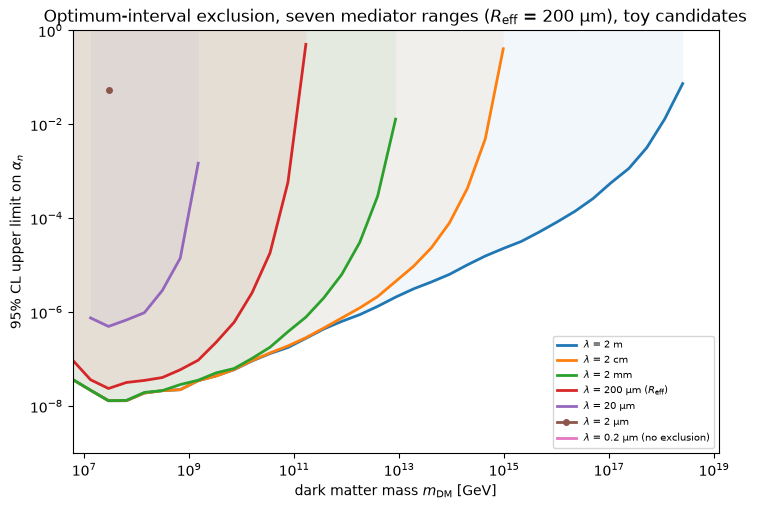

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 5.2))
for label, xs, color in XSECS:
    a_oi = scan[label]["a_oi"]
    ok = np.isfinite(a_oi)
    if ok.any():
        ax.fill_between(masses[ok], a_oi[ok], 1.0, color=color, alpha=0.06, lw=0)
        style = dict(marker="o", ms=4) if ok.sum() < 4 else {}
        ax.plot(masses[ok], a_oi[ok], "-", color=color, lw=2, label=label, **style)
    else:
        ax.plot([], [], "-", color=color, lw=2,
                label=label + " (no exclusion)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(masses.min(), M_PLANCK)
ax.set_ylim(1e-9, 1.0)
ax.set_xlabel(r"dark matter mass $m_{\rm DM}$ [GeV]")
ax.set_ylabel(r"95% CL upper limit on $\alpha_n$")
ax.set_title(rf"Optimum-interval exclusion, seven mediator ranges "
             rf"($R_{{\rm eff}}$ = {R_EFF * 1e6:.0f} µm), toy candidates")
ax.legend(fontsize=7, loc="lower right")
fig.tight_layout()
fig.savefig("../figures/uhdm_finite_range_exclusion.png", dpi=140)

## Understanding

### Anatomy at one mass

$\mu(\alpha_n)$ shows the finite-range **cliff**: below a critical coupling the
capped momentum transfer cannot reach the threshold at all and the expected
count collapses. The cliff moves right as the range shrinks (a smaller
$G_2 K_1$ needs more coupling to reach $q_\text{th}$). Above the cliff every
range eventually **saturates**: once all particles within reach already kick
above threshold, more coupling adds rate only logarithmically (the reach
beyond the sensor grows as $\lambda\ln\alpha$), so the plateaus stack in order
of $\lambda^2$. At this mass the 2 µm plateau sits at $\mu \approx 4.8$, which
pins its extremeness right at the 95% line in the lower panel (the marginal
exclusion of the results figure), and the 0.2 µm plateau at $\mu \approx 0.3$
never comes close.


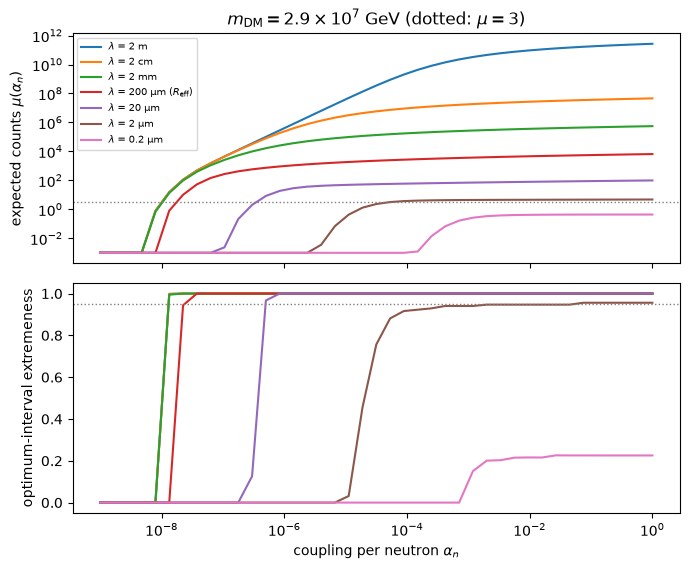

In [9]:
m_show = masses[np.argmin(np.abs(masses - 3e7))]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 5.8), sharex=True)
for label, xs, color in XSECS:
    ps, mus = [], []
    for a in alpha_scan:
        out = extremeness(a, m_show, xs)
        p, mu, _ = out if out is not None else (0.0, 0.0, 0)
        ps.append(p)
        mus.append(mu)
    ax1.loglog(alpha_scan, np.maximum(mus, 1e-3), "-", color=color, label=label)
    ax2.semilogx(alpha_scan, ps, "-", color=color)
ax1.axhline(3.0, color="#7f7f7f", lw=1, ls=":")
ax1.set_ylabel(r"expected counts $\mu(\alpha_n)$")
e_show = int(np.floor(np.log10(m_show)))
ax1.set_title(rf"$m_{{\rm DM}} = {m_show / 10**e_show:.1f}\times10^{{{e_show}}}$ GeV "
              rf"(dotted: $\mu = 3$)")
ax1.legend(fontsize=7, loc="upper left")
ax2.axhline(CONFIDENCE, color="#7f7f7f", lw=1, ls=":")
ax2.set_ylabel("optimum-interval extremeness")
ax2.set_xlabel(r"coupling per neutron $\alpha_n$")
fig.tight_layout()

### Method comparison at one range

For $\lambda$ = 200 µm ($= R_\text{eff}$): the optimum interval vs Poisson
counting with the same candidates, and the zero-event ideal. The gain appears
at masses whose spectra extend past the threshold cluster; near the cliff the
window is narrow and every method degenerates to counting.


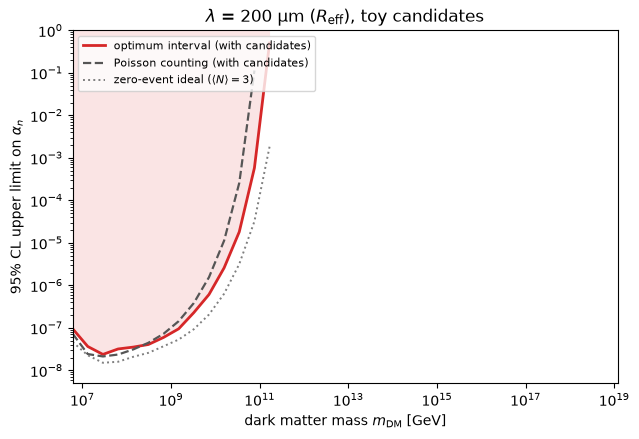

In [10]:
lab_ref = LAMBDAS[3][0]
col_ref = LAMBDAS[3][2]
ref = scan[lab_ref]
ok = np.isfinite(ref["a_oi"])
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.fill_between(masses[ok], ref["a_oi"][ok], 1.0, color=col_ref, alpha=0.12, lw=0)
ax.plot(masses[ok], ref["a_oi"][ok], "-", color=col_ref, lw=2,
        label="optimum interval (with candidates)")
ax.plot(masses, ref["a_pois"], "--", color="#555555", lw=1.6,
        label="Poisson counting (with candidates)")
ax.plot(masses, ref["a_ideal"], ":", color="#7f7f7f", lw=1.4,
        label=r"zero-event ideal ($\langle N\rangle = 3$)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(masses.min(), M_PLANCK)
ax.set_ylim(np.nanmin(ref["a_ideal"]) / 3, 1.0)
ax.set_xlabel(r"dark matter mass $m_{\rm DM}$ [GeV]")
ax.set_ylabel(r"95% CL upper limit on $\alpha_n$")
ax.set_title(lab_ref + ", toy candidates")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()

## Takeaways

- **The package scope stayed put.** All the mediator/halo physics lives in
  this notebook; the statistics went through three primitives
  (`generate` / `optimum_interval_statistic` / `extremeness_of_opt_itv_stat`)
  evaluated on a coupling grid, shared across all seven mediator ranges. When
  your signal shape depends on the parameter you are limiting, this is the
  pattern.
- **The momentum cap $K_1(R_\text{eff}/\lambda)$ organizes everything.** It
  sets the coupling floor (the $\mu$ cliff) and, through reach saturation
  ($\sigma_\text{sat} \sim \lambda^2$, growing only logarithmically in
  $\alpha$), the high-mass endpoint of every island: each factor of 10 in
  $\lambda$ buys roughly a factor of 100 in mass reach, and no finite range
  reaches the Planck mass.
- **Marginal channels stay marginal in coupling.** At $\lambda$ = 2 µm the
  saturated $\mu \approx 4.8$ sits at the edge of what five candidates allow,
  and at 0.2 µm ($\mu \le 0.4$) exclusion is out of reach entirely; more
  exposure or a cleaner candidate set, not more coupling, is what would open
  those channels.
- **The optimum interval helps where there is room to be empty.** At low mass
  the support window is narrow and filled by the threshold cluster, so it
  tracks plain counting (paying a small calibration cost); at high mass the
  window extends past the outlier and the empty stretch wins.
- **Extensions** drop in as different inputs to the same pipeline: atmospheric
  attenuation replaces $f(v)$ with the slowed distribution at the detector
  (making the shape depend on $\alpha_n$ even more strongly; the same grid
  handles it); $\lambda \to \infty$ recovers the massless-mediator tutorial.
- All parameters are fiducial; kicks are toys, not data.
